<a href="https://colab.research.google.com/github/markajbell/BH/blob/main/ShortestPath-6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [2]:
import pandas as pd
import json
import os
import glob

Set the Path to the Data location (imported form SharpHound)

# Set the Path
to the Data location (imported from SharpHound) and Read json files in folder and create a dictionary with the entire data.





In [3]:
!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure.json
#!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure10k.json

!mkdir = "/content/adsync"
!mv secure.json /content/adsync
#!mv secure10k.json /content/adsync

path = "/content/adsync"
data = {}
json_files = glob.glob(os.path.join(path, "*.json"))
for file in json_files:
    filename = os.path.basename(file).replace(".json", "")
    suf = filename.split("_")[-1]

    with open(file, 'r', encoding='utf-8') as f:
        content = json.load(f)

    if "data" in content:
        if suf in data:
            data[f"{suf}"].extend(content["data"])
            #print(f" The key 'data' was found in {f}.")
        else:
            data[f"{suf}"] = content["data"]
            #print(f" The key 'data' was found in {f}.")
    else:
        print(f"Warning: The key 'data' was not found in {f}.")

--2025-07-28 09:25:04--  https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1314149 (1.3M) [text/plain]
Saving to: ‘secure.json’

secure.json         100%[===================>]   1.25M  --.-KB/s    in 0.07s   

2025-07-28 09:25:04 (18.8 MB/s) - ‘secure.json’ saved [1314149/1314149]



Show the "content"

In [4]:
#content


In [29]:
# prompt: if the type column = "node" save that record into a pandas dataframe called nodes, if the type = "relationship' then save to a pandas dataframe called edges

import pandas as pd
df = pd.DataFrame(data[suf])
nodes = df[df['type'] == 'node'].copy()
edges = df[df['type'] == 'relationship'].copy()
nodes['id'] = nodes['id'].astype(int)

In [6]:
# prompt: what is the length of nodes['id] for the last record


In [30]:
nodes.tail()

#print(len(nodes["id"].iloc[-1]))

,id,labels,properties,type,start,end,label
1292,1292,"[Base, Group]","{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder45_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2009', 'distinguishedname': 'CN=T2_HR_FOLDER45_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,NaN,NaN,NaN
1293,1293,"[Base, Group]","{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder46_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2010', 'distinguishedname': 'CN=T2_HR_FOLDER46_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,NaN,NaN,NaN
1294,1294,"[Base, Group]","{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder47_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2011', 'distinguishedname': 'CN=T2_HR_FOLDER47_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,NaN,NaN,NaN
1295,1295,"[Base, Group]","{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder48_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2012', 'distinguishedname': 'CN=T2_HR_FOLDER48_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,NaN,NaN,NaN
1296,1296,"[Base, Group]","{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder49_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2013', 'distinguishedname': 'CN=T2_HR_FOLDER49_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,NaN,NaN,NaN


In [8]:
# prompt: show all rows


pd.set_option('display.max_rows', None)



In [31]:
# prompt: for every record in "nodes" create a l1, l2 and l3 column for the values in "nodes.labels" eg. for record 1 l1=Base, l2=OU and l3 would be null

import pandas as pd
def extract_labels(labels):
    # Ensure labels is a list
    if not isinstance(labels, list):
        return [None, None, None]

    l1 = labels[0] if len(labels) > 0 else None
    l2 = labels[1] if len(labels) > 1 else None
    l3 = labels[2] if len(labels) > 2 else None
    return [l1, l2, l3]

# Apply the function to create the new columns
nodes[['l1', 'l2', 'l3']] = nodes['labels'].apply(lambda x: pd.Series(extract_labels(x)))


In [32]:
# prompt: remove the following columns from nodes:
# start, end, label

nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])


In [33]:

edges = edges.drop(columns=['labels'])


Expand "Properties" column in new columns.

Convert to Dict

In [12]:
pd.set_option("display.max_rows", None, "display.max_columns", None)

#nodes

In [34]:
#edges = edges.drop(columns=['id'])
import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')


In [14]:
# prompt: save the df_compuers as json to content

# import json

# # Assuming df_computers is already defined as in your provided code.

# # Convert the DataFrame to a JSON string.
# nodes_json = nodes.to_json(orient='records')

# # Save the JSON string to a file named 'content.json'.
# with open('nodes.json', 'w') as f:
#   f.write(nodes_json)


In [15]:
# prompt: save the df_compuers as json to content

# import json

# # Assuming df_computers is already defined as in your provided code.

# # Convert the DataFrame to a JSON string.
# edges_json = edges.to_json(orient='records')

# # Save the JSON string to a file named 'content.json'.
# with open('edges.json', 'w') as f:
#   f.write(edges_json)

In [35]:
# prompt: create a new column in nodes called weight

nodes['weight'] = 1

In [36]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
pd.set_option('display.max_colwidth', None)

nodes.tail()

,id,properties,type,l1,l2,l3,weight
1292,1292,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder45_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2009', 'distinguishedname': 'CN=T2_HR_FOLDER45_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
1293,1293,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder46_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2010', 'distinguishedname': 'CN=T2_HR_FOLDER46_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
1294,1294,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder47_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2011', 'distinguishedname': 'CN=T2_HR_FOLDER47_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
1295,1295,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder48_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2012', 'distinguishedname': 'CN=T2_HR_FOLDER48_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
1296,1296,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder49_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2013', 'distinguishedname': 'CN=T2_HR_FOLDER49_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1


In [37]:
lastnode=(len(str(nodes['id'].iloc[-1])))

new_node_id = int('9' * lastnode)

print(f"The new node ID is: {new_node_id}")

The new node ID is: 9999


In [38]:
#prompt: create a new record in nodes where id=new_node_id, properties = {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-99999', 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False}, type=node, l1=ALL_T0, l2=ALL_T0, l3=ALL_T0

# Create a dictionary with the new record's data
new_node_data = {
    'id': new_node_id,
    'properties': {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-' + str(new_node_id), 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False},
    'type': 'node',
    'l1': 'ALL_T0',
    'l2': 'ALL_T0',
    'l3': 'ALL_T0',
    'weight': int(100) # Assuming a default weight, you can adjust if needed
}
#new_node_data

# Convert the dictionary to a DataFrame
new_node_df = pd.DataFrame([new_node_data])

# Concatenate the new DataFrame with the existing nodes DataFrame
nodes = pd.concat([nodes, new_node_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Nodes DataFrame after adding the new record:")
display(nodes.tail())

Nodes DataFrame after adding the new record:


,id,properties,type,l1,l2,l3,weight
1293,1293,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder46_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2010', 'distinguishedname': 'CN=T2_HR_FOLDER46_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
1294,1294,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder47_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2011', 'distinguishedname': 'CN=T2_HR_FOLDER47_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
1295,1295,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder48_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2012', 'distinguishedname': 'CN=T2_HR_FOLDER48_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
1296,1296,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder49_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2013', 'distinguishedname': 'CN=T2_HR_FOLDER49_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
1297,9999,"{'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-9999', 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False}",node,ALL_T0,ALL_T0,ALL_T0,100


In [39]:
#1/0
# tier0_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 0' in x.get('distinguishedname', ''))]['id'].tolist()
# tier0_node_ids

tier0_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 0', 'Tier 0', 'T0', 'TIER0']
        )
    )
]['id'].tolist()


tier1_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 1', 'Tier 1', 'T1']
        )
    )
]['id'].tolist()

tier2_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 2', 'Tier 2', 'T2']
        )
    )
]['id'].tolist()

print(f"tier 0 ",len(tier0_node_ids))
# tier1_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 1' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 1 ",len(tier1_node_ids))

# tier2_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 2' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 2 ",len(tier2_node_ids))

tier 0  43
tier 1  58
tier 2  949


In [41]:
# prompt: for each value in tier0_node_ids add a new record in edges where start = value and end = new_node_id, label=TIER0,weight=100 id=id+1

# Get the maximum existing edge ID
max_edge_id = edges['id'].max()
max_edge_id
new_edges = []
for i, tier0_id in enumerate(tier0_node_ids):
    new_edge = {
        'type': 'relationship',  # Assuming type is always 'relationship' for edges
        'start': tier0_id,
        'end': new_node_id,
        'label': 'TIER0',
        'weight': 100,
        'id': max_edge_id + i + 1 # Assign a unique ID
    }
    new_edges.append(new_edge)

# Convert the list of new edges to a DataFrame
new_edges_df = pd.DataFrame(new_edges)

# Concatenate the new edges DataFrame with the existing edges DataFrame
edges = pd.concat([edges, new_edges_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Edges DataFrame after adding new TIER0 edges:")
display(edges.tail())

Edges DataFrame after adding new TIER0 edges:


,id,properties,type,start,end,label,weight
4012,4012,NaN,relationship,653,9999,TIER0,100.0
4013,4013,NaN,relationship,663,9999,TIER0,100.0
4014,4014,NaN,relationship,686,9999,TIER0,100.0
4015,4015,NaN,relationship,692,9999,TIER0,100.0
4016,4016,NaN,relationship,9999,9999,TIER0,100.0


In [46]:
# Iterate through nodes and add a 'Tier0' column
nodes['Tier0'] = 0  # Initialize 'Tier0' column with 0
nodes['Tier1'] = 0  # Initialize 'Tier0' column with 0
nodes['Tier2'] = 0  # Initialize 'Tier0' column with 0

# Set 'Tier0' to 1 if node id is in tier0_node_ids
nodes.loc[nodes['id'].isin(tier0_node_ids), 'Tier0'] = 1
nodes.loc[nodes['id'].isin(tier1_node_ids), 'Tier1'] = 1
nodes.loc[nodes['id'].isin(tier2_node_ids), 'Tier2'] = 1

# Display the updated nodes DataFrame (optional)
display(nodes.head(60))
display(nodes.tail(60))

,id,properties,type,l1,l2,l3,weight,Tier0,Tier1,Tier2
0,0,"{'domain': 'MARK.LOCAL', 'name': 'MARK.LOCAL', 'highvalue': True, 'objectid': 'S-1-5-21-883232822-274137685-4173207997', 'distinguishedname': 'DC=MARK,DC=LOCAL', 'functionallevel': '2012', 'owned': False}",node,Base,Domain,None,1,NaN,NaN,NaN
1,1,"{'domain': 'MARK.LOCAL', 'name': 'Admin@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-cdca22b1-d164-4ec1-8233-45c0ea9044ac', 'distinguishedname': 'OU=ADMIN,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1,NaN,NaN,NaN
2,2,"{'domain': 'MARK.LOCAL', 'name': 'Tier 1 Servers@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-f6d49f51-1ea3-4d9c-93a1-0b591b59c7e9', 'distinguishedname': 'OU=TIER 1 SERVERS,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1,NaN,1.0,NaN
3,3,"{'domain': 'MARK.LOCAL', 'name': 'Tier 2@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-5de20ac8-e7ff-4f05-b597-268af392400e', 'distinguishedname': 'OU=TIER 2,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1,NaN,NaN,1.0
4,4,"{'domain': 'MARK.LOCAL', 'name': 'T0 Admin@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-f249f685-d5e0-4dad-b5b5-7f723c41ca1e', 'distinguishedname': 'OU=T0 ADMIN,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1,1.0,NaN,NaN
5,5,"{'domain': 'MARK.LOCAL', 'name': 'T1 Admin@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-8355af01-1b4e-48c8-8977-a53870b2770b', 'distinguishedname': 'OU=T1 ADMIN,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1,NaN,1.0,NaN
6,6,"{'domain': 'MARK.LOCAL', 'name': 'T2 Admin@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-e4602f9d-12bf-4f9e-b667-f6ccd27fae90', 'distinguishedname': 'OU=T2 ADMIN,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1,NaN,NaN,1.0
7,7,"{'domain': 'MARK.LOCAL', 'name': 'T0 Admin Accounts@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-c0fb853d-9b96-449b-b25c-4d20a1c02e5f', 'distinguishedname': 'OU=T0 ADMIN ACCOUNTS,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1,1.0,NaN,NaN
8,8,"{'domain': 'MARK.LOCAL', 'name': 'T0 Admin Devices@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-b9fd1aed-b3e6-4d53-9242-b85ff389822f', 'distinguishedname': 'OU=T0 ADMIN DEVICES,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1,1.0,NaN,NaN
9,9,"{'domain': 'MARK.LOCAL', 'name': 'T0 Admin Groups@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-cd13b9d6-76ca-4b5c-82bd-2d86bef8a375', 'distinguishedname': 'OU=T0 ADMIN GROUPS,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1,1.0,NaN,NaN


Here


In [24]:
for nodes['id'] in tier0_node_ids:
  print(nodes['id'].unique)

Streaming output truncated to the last 5000 lines.
196     663
197     663
198     663
199     663
200     663
201     663
202     663
203     663
204     663
205     663
206     663
207     663
208     663
209     663
210     663
211     663
212     663
213     663
214     663
215     663
216     663
217     663
218     663
219     663
220     663
221     663
222     663
223     663
224     663
225     663
226     663
227     663
228     663
229     663
230     663
231     663
232     663
233     663
234     663
235     663
236     663
237     663
238     663
239     663
240     663
241     663
242     663
243     663
244     663
245     663
246     663
247     663
248     663
249     663
250     663
251     663
252     663
253     663
254     663
255     663
256     663
257     663
258     663
259     663
260     663
261     663
262     663
263     663
264     663
265     663
266     663
267     663
268     663
269     663
270     663
271     663
272     663
273     663
274     663
2

In [ ]:
tier0_node_ids[-6:]

[12924, 12948, 12953, 12971, 12977, 99999]

In [ ]:
# prompt: find records from nodes where distinguishedname has "CN=Enterprise Admins," or  distinguishedname has "CN=Domain Admins,"  then append id to tier0_node_ids if not already present

# Assuming 'nodes' DataFrame is already defined from the preceding code

# Initialize an empty list to store the IDs
#tier0_node_ids = []

# Iterate through each row of the 'nodes' DataFrame
# for index, row in nodes.iterrows():
#     properties = row['properties']
#     node_id = row['id']

#     # Check if 'properties' is a dictionary and contains 'distinguishedname'
#     if isinstance(properties, dict) and 'distinguishedname' in properties:
#         distinguishedname = properties['distinguishedname']

#         # Check if "CN=Enterprise Admins," or "CN=Domain Admins," is in the distinguishedname
#         if "CN=Enterprise Admins," in distinguishedname or "CN=Domain Admins," in distinguishedname:
#             # Append the id if it's not already in the list
#             if node_id not in tier0_node_ids:
#                 tier0_node_ids.append(node_id)

# print(f"tier 0 (including 'CN=Enterprise Admins,' or 'CN=Domain Admins,'): {len(tier0_node_ids)}")
# # The existing prints for tier1 and tier2 will remain the same
# print(f"tier 1 : {len(tier1_node_ids)}")
# print(f"tier 2 : {len(tier2_node_ids)}")
# print("Tier 0 Node IDs:", tier0_node_ids)

In [ ]:
# prompt: show me the last 5 entries in tier0_node_ids

print(tier0_node_ids[-5:])

In [ ]:
# prompt: find records from nodes where 'admincount' = True and 'highvalue' = True and  (distinguishedname has "T0" or "Tier 0" or "TIER 0")

# Filter nodes based on conditions
# filtered_node = nodes[
#     nodes['properties'].apply(
#         lambda x: x.get('admincount', False) == "True" and
#                   x.get('highvalue', False) == "True" and
#                   any(term in x.get('distinguishedname', '') for term in ["T0", "Tier 0", "TIER 0"])
#     )
# ]

# # Display the filtered nodes
# print("Records where 'admincount' and 'highvalue' are True, and distinguishedname contains 'T0', 'Tier 0', or 'TIER 0':")

# filtered_node

In [ ]:
len(tier0_node_ids)

518

In [55]:
# prompt: find records from nodes where "objectid" ends with match(r'.*-\d{3}$' and highvalue=true and admincount=true.

import re

# Filter nodes where 'objectid' ends with a dash followed by exactly three digits,
# 'highvalue' is True, and 'admincount' is True.
filtered_nodes = nodes[
    nodes['properties'].apply(
        lambda x: re.search(r'.*-\d{3}$', x.get('objectid', '')) is not None and
                  x.get('highvalue', False) == True and
                  x.get('admincount', False) == True
    )
]

# Display the filtered nodes
print("Records where 'objectid' ends with - followed by three digits, and 'highvalue' and 'admincount' are True:")


filtered_nodes

,id,properties,type,l1,l2,l3,weight,Tier0,Tier1,Tier2
36,36,"{'domain': 'MARK.LOCAL', 'name': 'ADMINISTRATORS@MARK.LOCAL', 'objectid': 'MARK.LOCAL-S-1-5-32-544', 'highvalue': True, 'distinguishedname': 'CN=Administrators,CN=Builtin,DC=MARK,DC=LOCAL', 'description': 'Administrators have complete and unrestricted access to the computer/domain', 'admincount': True, 'owned': False}",node,Base,Group,None,20,NaN,NaN,NaN
38,38,"{'domain': 'MARK.LOCAL', 'name': 'PRINT OPERATORS@MARK.LOCAL', 'objectid': 'MARK.LOCAL-S-1-5-32-550', 'highvalue': True, 'distinguishedname': 'CN=Print Operators,CN=Builtin,DC=MARK,DC=LOCAL', 'description': 'Members can administer printers installed on domain controllers', 'admincount': True, 'owned': False}",node,Base,Group,None,20,NaN,NaN,NaN
40,40,"{'domain': 'MARK.LOCAL', 'name': 'BACKUP OPERATORS@MARK.LOCAL', 'objectid': 'MARK.LOCAL-S-1-5-32-551', 'highvalue': True, 'distinguishedname': 'CN=Backup Operators,CN=Builtin,DC=MARK,DC=LOCAL', 'description': 'Backup Operators can override security restrictions for the sole purpose of backing up or restoring files', 'admincount': True, 'owned': False}",node,Base,Group,None,20,NaN,NaN,NaN
59,59,"{'domain': 'MARK.LOCAL', 'name': 'SERVER OPERATORS@MARK.LOCAL', 'objectid': 'MARK.LOCAL-S-1-5-32-549', 'highvalue': True, 'distinguishedname': 'CN=Server Operators,CN=Builtin,DC=MARK,DC=LOCAL', 'description': 'Members can administer domain servers', 'admincount': True, 'owned': False}",node,Base,Group,None,20,NaN,NaN,NaN
60,60,"{'domain': 'MARK.LOCAL', 'name': 'ACCOUNT OPERATORS@MARK.LOCAL', 'objectid': 'MARK.LOCAL-S-1-5-32-548', 'highvalue': True, 'distinguishedname': 'CN=Account Operators,CN=Builtin,DC=MARK,DC=LOCAL', 'description': 'Members can administer domain user and group accounts', 'admincount': True, 'owned': False}",node,Base,Group,None,20,NaN,NaN,NaN
65,65,"{'domain': 'MARK.LOCAL', 'name': 'ENTERPRISE ADMINS@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-519', 'highvalue': True, 'distinguishedname': 'CN=Enterprise Admins,CN=Users,DC=MARK,DC=LOCAL', 'description': 'Designated administrators of the enterprise', 'admincount': True, 'owned': False}",node,Base,Group,None,20,NaN,NaN,NaN
66,66,"{'domain': 'MARK.LOCAL', 'name': 'DOMAIN ADMINS@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-512', 'highvalue': True, 'distinguishedname': 'CN=Domain Admins,CN=Users,DC=MARK,DC=LOCAL', 'description': 'Designated administrators of the domain', 'admincount': True, 'owned': False}",node,Base,Group,None,20,NaN,NaN,NaN
72,72,"{'domain': 'MARK.LOCAL', 'name': 'DOMAIN CONTROLLERS@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-516', 'highvalue': True, 'distinguishedname': 'CN=Domain Controllers,CN=Users,DC=MARK,DC=LOCAL', 'description': 'All domain controllers in the domain', 'admincount': True, 'owned': False}",node,Base,Group,None,20,NaN,NaN,NaN


In [48]:
# prompt:  check if "id" from filtered_nodes is in tier0_node_ids, if not then append to tier0_node_ids

# Assuming filtered_nodes DataFrame is already defined from the preceding code

# Iterate through the 'id' column of the filtered_nodes DataFrame
for node_id in filtered_nodes['id']:
    # Check if the node_id is not already in tier0_node_ids
    if node_id not in tier0_node_ids:
        # Append the node_id to the tier0_node_ids list
        tier0_node_ids.append(node_id)

# Print the updated length and contents of tier0_node_ids
print(f"tier 0 (after checking filtered_nodes): {len(tier0_node_ids)}")
print("Updated Tier 0 Node IDs:", tier0_node_ids)


tier 0 (after checking filtered_nodes): 51
Updated Tier 0 Node IDs: [4, 7, 8, 9, 10, 295, 296, 301, 303, 305, 306, 307, 318, 324, 331, 341, 357, 392, 405, 444, 448, 457, 458, 467, 469, 481, 527, 530, 531, 532, 553, 607, 610, 625, 631, 632, 640, 645, 653, 663, 686, 692, 9999, 36, 38, 40, 59, 60, 65, 66, 72]


In [58]:
nodes.loc[nodes['id'].isin(tier0_node_ids), 'Tier0'] = 1
nodes.loc[nodes['id'].isin(tier1_node_ids), 'Tier1'] = 1
nodes.loc[nodes['id'].isin(tier2_node_ids), 'Tier2'] = 1
nodes.tail(60)

,id,properties,type,l1,l2,l3,weight,Tier0,Tier1,Tier2
1238,1238,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder38_Write@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1955', 'distinguishedname': 'CN=T2_HR_FOLDER38_WRITE,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1239,1239,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder39_Write@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1956', 'distinguishedname': 'CN=T2_HR_FOLDER39_WRITE,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1240,1240,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder40_Write@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1957', 'distinguishedname': 'CN=T2_HR_FOLDER40_WRITE,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1241,1241,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder41_Write@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1958', 'distinguishedname': 'CN=T2_HR_FOLDER41_WRITE,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1242,1242,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder42_Write@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1959', 'distinguishedname': 'CN=T2_HR_FOLDER42_WRITE,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1243,1243,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder43_Write@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1960', 'distinguishedname': 'CN=T2_HR_FOLDER43_WRITE,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1244,1244,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder44_Write@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1961', 'distinguishedname': 'CN=T2_HR_FOLDER44_WRITE,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1245,1245,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder45_Write@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1962', 'distinguishedname': 'CN=T2_HR_FOLDER45_WRITE,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1246,1246,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder46_Write@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1963', 'distinguishedname': 'CN=T2_HR_FOLDER46_WRITE,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1247,1247,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder0_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1964', 'distinguishedname': 'CN=T2_HR_FOLDER0_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': 

In [49]:
# prompt: CHANGE THE VALUES OF tier0_node_ids TO INT64

import numpy as np
tier0_node_ids = np.array(tier0_node_ids, dtype=np.int64)
print("Data type of tier0_node_ids:", tier0_node_ids.dtype)

Data type of tier0_node_ids: int64


In [50]:
# prompt: sort tier0_node_ids ascending

import numpy as np
tier0_node_ids = np.sort(tier0_node_ids)

# print("Sorted Tier 0 Node IDs:", tier0_node_ids)
# print("Data type of tier0_node_ids after sorting:", tier0_node_ids.dtype)
# print(f"tier 0 count (after sorting): {len(tier0_node_ids)}")
# print(tier0_node_ids[-5:])

In [59]:
tier0_node_ids

array([   4,    7,    8,    9,   10,   36,   38,   40,   59,   60,   65,
         66,   72,  295,  296,  301,  303,  305,  306,  307,  318,  324,
        331,  341,  357,  392,  405,  444,  448,  457,  458,  467,  469,
        481,  527,  530,  531,  532,  553,  607,  610,  625,  631,  632,
        640,  645,  653,  663,  686,  692, 9999])

In [60]:
filtered_nodes.dtypes

,0
id,int64
properties,object
type,object
l1,object
l2,object
l3,object
weight,int64
Tier0,float64
Tier1,float64
Tier2,float64


In [ ]:
nodes.keys()


In [61]:
len(tier0_node_ids)

51

In [ ]:
len(nodes)

In [ ]:
nodes.tail()

In [62]:

for value in tier0_node_ids:
    if value  == new_node_id:
        nodes.loc[nodes['id'] == value, 'weight'] = 100
    else:
        nodes.loc[nodes['id'] == value, 'weight'] = 20

for value in tier1_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 10

for value in tier2_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 5

nodes.tail()

,id,properties,type,l1,l2,l3,weight,Tier0,Tier1,Tier2
1293,1293,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder46_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2010', 'distinguishedname': 'CN=T2_HR_FOLDER46_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1294,1294,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder47_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2011', 'distinguishedname': 'CN=T2_HR_FOLDER47_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1295,1295,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder48_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2012', 'distinguishedname': 'CN=T2_HR_FOLDER48_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1296,1296,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder49_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2013', 'distinguishedname': 'CN=T2_HR_FOLDER49_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,NaN,NaN,1.0
1297,9999,"{'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-9999', 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False}",node,ALL_T0,ALL_T0,ALL_T0,100,1.0,NaN,NaN


In [63]:
# prompt: get a unique list of label from edges and save it to list called edges_labels

edges_labels = edges['label'].unique().tolist()
edges_labels

['Contains',
 'GpLink',
 'GenericAll',
 'MemberOf',
 'GenericWrite',
 'WriteDacl',
 'Owns',
 'WriteOwner',
 'GetChanges',
 'GetChangesAll',
 'AllExtendedRights',
 'AdminTo',
 'HasSession',
 'ReadLAPSPassword',
 'CanRDP',
 'ExecuteDCOM',
 'AddSelf',
 'ForceChangePassword',
 'AddMember',
 'TIER0']

In [64]:
# Apply the weights based on the 'label' column

def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 1
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "HasSession":
        return 9
    elif label == "ReadLAPSPassword":
        return 2
    elif label == "GetChanges":
        return 3
    elif label == "GetChangesAll":
        return 3
    elif label == "AddSelf":
        return 3
    elif label == "ForceChangePassword":
        return 3
    elif label == "AddMember":
        return 5
    elif label == "AllowedToDelegate":
        return 5
    elif label == "AllowedToAct":
        return 4
    elif label == "TIER0":
        return 100
    else:
        return 1 # Default weight for other labels

edges['weight'] = edges['label'].apply(assign_weight)

# Display the updated edges_all DataFrame with the 'weight' column
print("\nEdges_all DataFrame with weight column:")
#edges.head(50)
#clear_output()


Edges_all DataFrame with weight column:


In [65]:
# prompt: from edges['start'] get 'id' and from edges['end] get 'id'
# replace start with edges['start'][id'] and  end with edges['end']['id']

edges['start'] = edges['start'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)
edges['end'] = edges['end'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)

In [ ]:
len(edges)

In [ ]:
print("\nEdges_all DataFrame with weight column:")
edges.tail(60)

In [66]:

edges = edges.drop(columns=['properties']) #, 'id'])

In [67]:
# prompt: create a unique id for each row, make sure it is of type int64
#edges = edges.drop(columns=['id'])
import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')
edges.head()
edges['id'].dtype

dtype('int64')

In [ ]:
# prompt: create a unique id for each row, make sure it is of type int64

import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')

In [ ]:

edges.keys()

In [68]:
edges.head()

,id,type,start,end,label,weight
0,0,relationship,0,1,Contains,2
1,1,relationship,0,2,Contains,2
2,2,relationship,0,3,Contains,2
3,3,relationship,1,4,Contains,2
4,4,relationship,1,5,Contains,2


In [69]:
edges.tail()

,id,type,start,end,label,weight
4012,4012,relationship,653,9999,TIER0,100
4013,4013,relationship,663,9999,TIER0,100
4014,4014,relationship,686,9999,TIER0,100
4015,4015,relationship,692,9999,TIER0,100
4016,4016,relationship,9999,9999,TIER0,100


In [71]:
# prompt: make edges['start'] and edges['end'] int64

edges['start'] = edges['start'].astype('int64')
edges['end'] = edges['end'].astype('int64')
edges['weight'] = edges['weight'].astype('int64')

In [72]:
# prompt: filter where edges['id'] = tier2_node_ids and call the dataframe selected_ddges

selected_edges = edges[edges['end'].isin(tier0_node_ids)]
len(selected_edges)

281

In [73]:
edges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4017 entries, 0 to 4016
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      4017 non-null   int64 
 1   type    4017 non-null   object
 2   start   4017 non-null   int64 
 3   end     4017 non-null   int64 
 4   label   4017 non-null   object
 5   weight  4017 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 188.4+ KB


In [74]:
# prompt: selected_edges_t0 = edges[edges['end'].isin(tier0_node_ids)] and selected_edges_t0=edges[edges'start'] is not in tier0_node_ids

selected_edges_t0 = edges[
    (edges['end'].isin(tier0_node_ids))
#    & (~edges['start'].isin(tier0_node_ids))
]
len(selected_edges_t0)

281

In [ ]:
selected_edges_t1 = edges[edges['start'].isin(tier1_node_ids)]
#selected_edges_t1
selected_edges_t2 = edges[edges['start'].isin(tier2_node_ids)]
#selected_edges_t2

In [75]:
selected_nodes = nodes[nodes['id'].isin(tier2_node_ids)]

In [76]:
len(selected_nodes)

949

In [ ]:
nodes.tail()

In [ ]:
len(edges)

In [77]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes with their weights
for index, row in selected_nodes.iterrows():
    # Ensure node IDs are integers when adding to the graph
    G.add_node(int(row['id']), weight=row['weight'])

# Add edges with their weights
for index, row in selected_edges_t0.iterrows():
    # Ensure edge endpoints are integers when adding to the graph
    G.add_edge(row['start'], row['end'], weight=row['weight'])

# Compute shortest paths from each source node to all reachable nodes
shortest_paths = {}
for source in G.nodes():
    # Use single_source_dijkstra_path to find paths from one source to all others
    shortest_paths[source] = nx.single_source_dijkstra_path(G, source)

# Filter out paths from a node to itself and store in a new dictionary
shortest_paths_filtered = {
    source: {
        target: path
        for target, path in paths.items()
        if source != target
        #if target in tier0_node_ids
        #if source in tier0_node_ids
    }
    for source, paths in shortest_paths.items()
}

# Print the shortest paths (optional)
for source, paths in shortest_paths_filtered.items():
  if paths:
    #print(f"Shortest paths from node {source}:")
    for target, path in paths.items():
        #print(f"  To node {target}: {path}")
        ShortestPath = source, target, path
       # print(ShortestPath)

In [78]:
shortest_paths_filtered

{3: {},
 6: {},
 15: {301: [15, 301], 318: [15, 318], 9999: [15, 301, 9999]},
 16: {},
 17: {},
 18: {},
 22: {},
 23: {},
 24: {},
 25: {},
 26: {331: [26, 331],
  341: [26, 341],
  357: [26, 357],
  405: [26, 405],
  444: [26, 444],
  448: [26, 448],
  9999: [26, 331, 9999]},
 27: {392: [27, 392], 9999: [27, 392, 9999]},
 28: {},
 29: {481: [29, 481], 9999: [29, 481, 9999]},
 30: {},
 31: {},
 32: {},
 33: {},
 34: {},
 35: {},
 71: {},
 83: {},
 94: {},
 95: {},
 96: {},
 97: {},
 289: {},
 290: {},
 292: {},
 293: {},
 294: {},
 298: {},
 299: {},
 300: {},
 301: {9999: [301, 9999]},
 304: {},
 308: {},
 310: {},
 311: {},
 312: {},
 313: {},
 314: {},
 316: {},
 317: {},
 318: {9999: [318, 9999]},
 320: {},
 321: {},
 322: {},
 325: {},
 326: {},
 327: {},
 328: {},
 329: {},
 330: {},
 331: {9999: [331, 9999]},
 332: {},
 333: {},
 334: {},
 335: {},
 336: {},
 337: {},
 338: {},
 339: {},
 340: {},
 341: {9999: [341, 9999]},
 342: {},
 343: {},
 344: {},
 345: {},
 346: {},
 347

In [ ]:
edges.tail()

In [79]:
# prompt: show only records where shortest_paths_filtered is not empty. Sort by source

import pandas as pd
# Convert the dictionary to a list of dictionaries
data_list = []
for source, paths in shortest_paths_filtered.items():
    for target, path in paths.items():
        data_list.append({'source': source, 'target': target, 'path': path})

# Create a DataFrame from the list of dictionaries
shortest_paths_df = pd.DataFrame(data_list)

# Filter out records where the 'path' is empty (which implies shortest_paths_filtered is not empty for that source-target pair)
# Since we constructed the DataFrame only from non-empty paths, this step is redundant based on the previous loop,
# but it's good practice if the filtering logic changed.
# A more direct way to check for non-empty paths after DataFrame creation would involve examining the 'path' column length.
# However, the current structure of `data_list` creation ensures that only non-empty paths are included.

# Sort by 'source'
shortest_paths_df_sorted = shortest_paths_df.sort_values(by='source')

# Print the resulting DataFrame
#shortest_paths_df_sorted

In [ ]:
shortest_paths_df_sorted

In [80]:
# prompt: using the above code, save all ShortestPath to a json file

shortest_paths_list = []
for source, paths in shortest_paths_filtered.items():
    if paths:
        for target, path in paths.items():
            shortest_paths_list.append({
                'source': source,
                'target': target,
                'path': path,
            })

with open('shortest_paths.json', 'w') as f:
    json.dump(shortest_paths_list, f, indent=4)

print("Shortest paths saved to shortest_paths.json")


Shortest paths saved to shortest_paths.json


In [ ]:
# prompt: save the df_compuers as json to content

# import json

# # Assuming df_computers is already defined as in your provided code.

# # Convert the DataFrame to a JSON string.
# selected_edges_json = selected_edges_t2.to_json(orient='records')

# # Save the JSON string to a file named 'content.json'.
# with open('selected_edges_t2.json', 'w') as f:
#   f.write(selected_edges_json)

In [81]:
# prompt: save the df_compuers as json to content

import json

# Assuming df_computers is already defined as in your provided code.

# Convert the DataFrame to a JSON string.
selected_nodes_json = selected_nodes.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('selected_nodes.json', 'w') as f:
  f.write(selected_nodes_json)


In [82]:
# prompt: export shortest_paths_filtered to json and save as shortest_paths_filtered_json

shortest_paths_filtered_json = json.dumps(ShortestPath, indent=2)

# Optionally, save the JSON string to a file
with open('ShortestPath.json', 'w') as f:
  f.write(shortest_paths_filtered_json)

In [83]:
# prompt: find the corresponding record in edges where (edges['start']=shortest_paths_list['source']) and (edges['end']=shortest_paths_list['target'] and then add up the weight

# Calculate the total weight for each shortest path
shortest_paths_with_weight = []
for path_info in shortest_paths_list:
    total_weight = 0
    # The path is a list of node IDs
    path = path_info['path']
    # Iterate through the path to get the edges
    for i in range(len(path) - 1):
        start_node = path[i]
        end_node = path[i+1]
        # Find the corresponding edge in the 'edges' DataFrame
        # There might be multiple edges between two nodes, so we sum up weights if needed
        # For shortest path, we typically consider the direct edge weight

        edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
        if not edge.empty:
            # Assuming there is only one edge with this start and end for simplicity in path finding
            # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
            total_weight += edge.iloc[0]['weight']
    path_info['total_weight'] = total_weight
    shortest_paths_with_weight.append(path_info)

# Print or use the shortest_paths_with_weight list
#for path_info in shortest_paths_with_weight:
 #   print(f"Path from {path_info['source']} to {path_info['target']}: {path_info['path']} - Total Weight: {path_info['total_weight']}")


In [86]:
# prompt: convert shortest_paths_with_weight to dataframe called df_shortest_paths_with_weight

import pandas as pd
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)

In [87]:
# prompt: show me df_filtered_paths where source is in tier2_node_ids and target is in tier0_node_ids

df_filtered_paths = df_shortest_paths_with_weight[
    (df_shortest_paths_with_weight['source'].isin(tier2_node_ids)) &
    (df_shortest_paths_with_weight['target'].isin(tier0_node_ids))
]

len(df_filtered_paths)

258

In [ ]:
edges.tail()

In [ ]:
df_shortest_paths_with_weight

In [ ]:
tier0_node_ids


In [ ]:
nodes.tail()

In [88]:
df_filtered_paths = df_shortest_paths_with_weight[
    #(~df_shortest_paths_with_weight['source'].isin(tier0_node_ids)) &
    (df_shortest_paths_with_weight['target'].isin(tier0_node_ids)) &
    (df_shortest_paths_with_weight['source'].isin(tier2_node_ids)) #&
    #(~df_shortest_paths_with_weight['target'].isin(tier2_node_ids))# &
    #(~df_shortest_paths_with_weight['target'].isin(tier1_node_ids)) &
    #(~df_shortest_paths_with_weight['source'].isin(tier1_node_ids))

].copy()

if not df_filtered_paths.empty:
    min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]
    max_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmax()]

    print("Min Weight Path:")
    print(f"  Source: {min_weight_row['source']}")
    print(f"  Target: {min_weight_row['target']}")
    print(f"  Path: {min_weight_row['path']}")
    print(f"  Weight: {min_weight_row['total_weight']}")

    print("\nMax Weight Path:")
    print(f"  Source: {max_weight_row['source']}")
    print(f"  Target: {max_weight_row['target']}")
    print(f"  Path: {max_weight_row['path']}")
    print(f"  Weight: {max_weight_row['total_weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")

Min Weight Path:
  Source: 700
  Target: 66
  Path: [700, 66]
  Weight: 1

Max Weight Path:
  Source: 705
  Target: 9999
  Path: [705, 60, 8, 9999]
  Weight: 110


In [89]:
min_weight = df_filtered_paths['total_weight'].min()
min_weight
max_weight = df_filtered_paths['total_weight'].max()
max_weight

110

In [90]:
#print(df_filtered_paths[df_filtered_paths['total_weight'] == min_weight])
#print(df_filtered_paths[df_filtered_paths['total_weight'] == max_weight])

min_weight_paths = pd.DataFrame(df_filtered_paths[df_filtered_paths['total_weight'] == min_weight])
max_weight_paths = pd.DataFrame(df_filtered_paths[df_filtered_paths['total_weight'] == max_weight])

In [91]:
print(min_weight_paths)
print(max_weight_paths)
#max_weight_paths

     source  target       path  total_weight
106     700      66  [700, 66]             1
144     705      60  [705, 60]             1
     source  target                path  total_weight
161     705    9999  [705, 60, 8, 9999]           110


In [ ]:
print(nodes[nodes['id'] == 12970])
print(nodes[nodes['id'] == 7940])
print(nodes[nodes['id'] == 99999])
# print(nodes[nodes['id'] == 610])
# print(nodes[nodes['id'] == 457])
# print(nodes[nodes['id'] == 66])
# print(nodes[nodes['id'] == 36])
#print(nodes[nodes['id'] == 60])


         id  \
6749  12970   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 properties  \
6749  {'name': 'WS-01977@TESTLAB.LOCALE', 'operatingsystem': 'Windows 10 Enterprise', 'enabled': True, 'haslaps': False, 'highvalue': False, 'lastlogontimestamp': 0, 'pwdlastset': 1715010676, 'serviceprincipalnames': 'TERMSRV/WS-01977@TESTLAB.LOCALE,

In [ ]:
print(min_weight_row)
print(max_weight_row)


source                  6236
target                  6433
path            [6236, 6433]
total_weight               2
Name: 0, dtype: object
source                         9672
target                        99999
path            [9672, 7278, 99999]
total_weight                    109
Name: 361, dtype: object


In [92]:
#df_filtered_paths
#df_filtered_paths_json =  df_filtered_paths.to_json(orient='records')
df_filtered_paths_json = df_filtered_paths.to_json(orient='records', indent=4)
# Save the JSON string to a file named 'content.json'.
with open('df_filtered_paths.json', 'w') as f:
  f.write(df_filtered_paths_json)

In [93]:
len(df_filtered_paths)

258

In [94]:
# prompt: convert shortest_paths_with_weight to dataframe called df_shortest_paths_with_weight

import pandas as pd
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)

In [95]:
df_shortest_paths_with_weight.keys()

Index(['source', 'target', 'path', 'total_weight'], dtype='object')

In [96]:
print(nodes[nodes['id'] == 700])
print(nodes[nodes['id'] == 66])
print(nodes[nodes['id'] == 705])
print(nodes[nodes['id'] == 60])
#print(nodes[nodes['id'] == 99999])
# print(nodes[nodes['id'] == 6460])
# print(nodes[nodes['id'] == 66])
# print(nodes[nodes['id'] == 65])

      id  \
700  700   

                                                                                                                                                                                                                                                                                                                                                                            properties  \
700  {'domain': 'MARK.LOCAL', 'name': 'T2 Distribution IT_AK@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1421', 'distinguishedname': 'CN=T2 DISTRIBUTION IT_AK,OU=T2 Distribution IT,OU=T2 Distribution Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a distribution group', 'highvalue': False, 'admincount': False, 'owned': False}   

     type    l1     l2    l3  weight  Tier0  Tier1  Tier2  
700  node  Base  Group  None       5    NaN    NaN    1.0  
    id  \
66  66   

                                                                             

In [ ]:
min_weight_row

,0
source,6236
target,6433
path,"[6236, 6433]"
total_weight,2


In [ ]:
# prompt: for value pairs max_weight_row['path'] show weights in edges

if not df_filtered_paths.empty:
    max_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].max()]
    print("\nMax Weight Path (with edge weights):")
    print(f"  Source: {max_weight_row['source']}")
    print(f"  Target: {max_weight_row['target']}")
    print(f"  Path: {max_weight_row['path']}")
    print(f"  Weight: {max_weight_row['total_weight']}")

    # Iterate through the path to show edge weights
    for i in range(len(max_weight_row['path']) - 1):
        max_path = max_weight_row['path']
        for i in range(len(max_path) - 1):
            start_node = max_path[i]
            end_node = max_path[i+1]
            edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
            if not edge.empty:
                print(f"    Edge from {start_node} to {end_node} (Label: {edge.iloc[0]['label']}): Weight = {edge.iloc[0]['weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")


Max Weight Path (with edge weights):
  Source: 6247
  Target: 6801
  Path: [6247, 6801]
  Weight: 2
    Edge from 6247 to 6801 (Label: Contains): Weight = 2


In [ ]:
max_path

[9672, 7278]

In [ ]:
print(nodes[nodes['id'] == 6290])
print(nodes[nodes['id'] == 6229])
print(nodes[nodes['id'] == 9924])
print(nodes[nodes['id'] == 6452])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])

      id  \
69  6290   

                                                                                                                                                                                                                                                                                                                             properties  \
69  {'domain': 'TESTLAB.LOCALE', 'name': 'ENTERPRISE ADMINS@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-519', 'highvalue': True, 'distinguishedname': 'CN=Enterprise Admins,CN=Users,DC=TESTLAB,DC=LOCALE', 'description': 'Designated administrators of the enterprise', 'admincount': True, 'owned': False}   

    type    l1     l2    l3  weight  
69  node  Base  Group  None      20  
     id  \
8  6229   

                                                                                                                                                                                                                     

In [ ]:
 #prompt: for value pairs max_weight_row['path'] show weights in edges

if not df_filtered_paths.empty:
    min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].min()]
    #min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]
    print("\nMin Weight Path (with edge weights):")
    print(f"  Source: {min_weight_row['source']}")
    print(f"  Target: {min_weight_row['target']}")
    print(f"  Path: {min_weight_row['path']}")
    print(f"  Weight: {min_weight_row['total_weight']}")

    # Iterate through the path to show edge weights
    for i in range(len(min_weight_row['path']) - 1):
        path = min_weight_row['path']
        for i in range(len(path) - 1):
            start_node = path[i]
            end_node = path[i+1]
            edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
            if not edge.empty:
                print(f"    Edge from {start_node} to {end_node} (Label: {edge.iloc[0]['label']}): Weight = {edge.iloc[0]['weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")


Min Weight Path (with edge weights):
  Source: 6236
  Target: 6458
  Path: [6236, 6458]
  Weight: 2
    Edge from 6236 to 6458 (Label: Contains): Weight = 2


In [ ]:
print(nodes[nodes['id'] == 6335])
print(nodes[nodes['id'] == 6229])
# print(nodes[nodes['id'] == 869])
# print(nodes[nodes['id'] == 8])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])

       id  \
114  6335   

                                                                                                                                                                               properties  \
114  {'domain': 'TESTLAB.LOCALE', 'name': 'PAW Configuration@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-91ce51b5-fabb-4ebc-9df9-74f19df3da3a', 'owned': False}   

     type    l1   l2    l3  weight  
114  node  Base  GPO  None       1  
     id  \
8  6229   

                                                                                                                                                                                                                                                                                                                  properties  \
8  {'domain': 'TESTLAB.LOCALE', 'name': 'T0 Admin Devices@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-3dd2e1a2-11ee-49c1-a49a-69921dadcc57', 'distingui

In [97]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight
min_total_weight = df_shortest_paths_with_weight['total_weight'].min()
# Filter the DataFrame to get rows with the minimum total weight
df_min_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == min_total_weight]
df_min_weight_paths = pd.DataFrame(df_min_weight_paths)
# Print the DataFrame with minimum total weight
print("\nPaths with the Minimum Total Weight:")
df_min_weight_paths


Paths with the Minimum Total Weight:


,source,target,path,total_weight
106,700,66,"[700, 66]",1
144,705,60,"[705, 60]",1
452,65,36,"[65, 36]",1
600,102,72,"[102, 72]",1
601,103,72,"[103, 72]",1
602,104,72,"[104, 72]",1
603,110,8,"[110, 8]",1
641,111,8,"[111, 8]",1
679,135,9,"[135, 9]",1
718,137,4,"[137, 4]",1


In [99]:
# prompt: filter df_shortest_paths_with_weight where start is not in tier0_node_ids

df_filtered = df_shortest_paths_with_weight[~df_shortest_paths_with_weight['source'].isin(tier0_node_ids)]
df_filtered = df_shortest_paths_with_weight[~df_shortest_paths_with_weight['target'].isin(tier2_node_ids)]
df_filtered

,source,target,path,total_weight
2,15,9999,"[15, 301, 9999]",102
9,26,9999,"[26, 331, 9999]",102
11,27,9999,"[27, 392, 9999]",102
13,29,9999,"[29, 481, 9999]",102
14,301,9999,"[301, 9999]",100
15,318,9999,"[318, 9999]",100
16,331,9999,"[331, 9999]",100
17,341,9999,"[341, 9999]",100
18,357,9999,"[357, 9999]",100
19,392,9999,"[392, 9999]",100


In [103]:
df_filtered

,source,target,path,total_weight
2,15,9999,"[15, 301, 9999]",102
9,26,9999,"[26, 331, 9999]",102
11,27,9999,"[27, 392, 9999]",102
13,29,9999,"[29, 481, 9999]",102
14,301,9999,"[301, 9999]",100
15,318,9999,"[318, 9999]",100
16,331,9999,"[331, 9999]",100
17,341,9999,"[341, 9999]",100
18,357,9999,"[357, 9999]",100
19,392,9999,"[392, 9999]",100


In [101]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight

min_total_weight = df_filtered['total_weight'].min()
# Filter the DataFrame to get rows with the minimum total weight
df_min_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == min_total_weight]
# Print the DataFrame with minimum total weight
print("\nPaths with the Minimum Total Weight:")
#df_min_weight_paths


Paths with the Minimum Total Weight:


In [102]:
df_min_weight_paths

,source,target,path,total_weight
106,700,66,"[700, 66]",1
144,705,60,"[705, 60]",1
452,65,36,"[65, 36]",1
600,102,72,"[102, 72]",1
601,103,72,"[103, 72]",1
602,104,72,"[104, 72]",1
603,110,8,"[110, 8]",1
641,111,8,"[111, 8]",1
679,135,9,"[135, 9]",1
718,137,4,"[137, 4]",1


In [104]:
print(nodes[nodes['id'] == 469])
print(nodes[nodes['id'] == 59])
# print(nodes[nodes['id'] == 869])
# print(nodes[nodes['id'] == 8])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])

      id  \
469  469   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 properties  \
469  {'domain': 'MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1194', 'displayname': 'Dustin Venning', 'name': 'DVENNING00184@MARK.LOCAL', 'enabled': True, 'pwdlastset': 0, 'lastlogon': 0, 'lastlogontimestamp': 0, 'highvalue': False, 'dontreqpreauth': False, 'hasspn': False, 'passwordnotreqd': False, 'pwdneverexpir

In [ ]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight

max_total_weight = df_filtered['total_weight'].max()
# Filter the DataFrame to get rows with the minimum total weight
df_max_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == max_total_weight]
df_max_weight_paths = df_max_weight_paths[
    #(~df_shortest_paths_with_weight['source'].isin(tier0_node_ids)) &
    (df_max_weight_paths['target'].isin(tier0_node_ids)) &
    (df_max_weight_paths['source'].isin(tier2_node_ids))
]
# Print the DataFrame with minimum total weight
print("\nPaths with the Maximum Total Weight:")
df_max_weight_paths


Paths with the Maximum Total Weight:


,source,target,path,total_weight
361,9672,99999,"[9672, 7278, 99999]",109
363,9676,99999,"[9676, 7705, 99999]",109
365,9680,99999,"[9680, 8865, 99999]",109
367,9684,99999,"[9684, 7705, 99999]",109
369,9685,99999,"[9685, 9364, 99999]",109
371,9688,99999,"[9688, 9320, 99999]",109
373,9701,99999,"[9701, 7381, 99999]",109
377,9704,99999,"[9704, 8442, 99999]",109
379,9715,99999,"[9715, 6781, 99999]",109
381,9720,99999,"[9720, 8154, 99999]",109


In [ ]:
# prompt: for each value in df_max_weight_paths['paths'] count the values and sort in ascending order with largest first

from collections import Counter

# Count the occurrences of each value in the 'paths' column
path_value_counts = Counter(item for sublist in df_max_weight_paths['path'] for item in sublist)

# Sort the counts in descending order (largest first)
sorted_path_value_counts = dict(sorted(path_value_counts.items(), key=lambda item: item[1], reverse=True))

print("\nCounts of values in paths (sorted in descending order):")
for value, count in sorted_path_value_counts.items():
    print(f"Value: {value}, Count: {count}")



Counts of values in paths (sorted in descending order):
Value: 99999, Count: 750
Value: 7301, Count: 11
Value: 7237, Count: 11
Value: 7801, Count: 11
Value: 7381, Count: 10
Value: 8154, Count: 10
Value: 8200, Count: 10
Value: 8325, Count: 10
Value: 7282, Count: 10
Value: 7500, Count: 10
Value: 7345, Count: 10
Value: 8865, Count: 9
Value: 8459, Count: 9
Value: 7670, Count: 9
Value: 7631, Count: 9
Value: 7157, Count: 9
Value: 7255, Count: 9
Value: 7918, Count: 9
Value: 6826, Count: 9
Value: 8853, Count: 9
Value: 7076, Count: 9
Value: 6838, Count: 9
Value: 7775, Count: 9
Value: 8442, Count: 8
Value: 6781, Count: 8
Value: 8378, Count: 8
Value: 7993, Count: 8
Value: 6830, Count: 8
Value: 7188, Count: 8
Value: 8199, Count: 8
Value: 7596, Count: 8
Value: 8623, Count: 8
Value: 8949, Count: 8
Value: 7829, Count: 8
Value: 8532, Count: 8
Value: 6800, Count: 8
Value: 7705, Count: 7
Value: 9320, Count: 7
Value: 7569, Count: 7
Value: 9610, Count: 7
Value: 7094, Count: 7
Value: 7415, Count: 7
Value:

In [ ]:
# prompt: for each value in df_max_weight_paths['paths'] count the values and sort in ascending order with largest first

from collections import Counter

# Count the occurrences of each value in the 'paths' column
min_path_value_counts = Counter(item for sublist in df_min_weight_paths['path'] for item in sublist)

# Sort the counts in descending order (largest first)
min_sorted_path_value_counts = dict(sorted(min_path_value_counts.items(), key=lambda item: item[1], reverse=True))

print("\nCounts of values in paths (sorted in descending order):")
for value, count in min_sorted_path_value_counts.items():
    print(f"Value: {value}, Count: {count}")


Counts of values in paths (sorted in descending order):
Value: 6285, Count: 28
Value: 6291, Count: 24
Value: 6263, Count: 20
Value: 6284, Count: 15
Value: 6371, Count: 8
Value: 6297, Count: 4
Value: 6290, Count: 2
Value: 6261, Count: 2
Value: 6229, Count: 2
Value: 6230, Count: 2
Value: 6327, Count: 1
Value: 6328, Count: 1
Value: 6329, Count: 1
Value: 6335, Count: 1
Value: 6336, Count: 1
Value: 6360, Count: 1
Value: 6362, Count: 1
Value: 6225, Count: 1
Value: 6364, Count: 1
Value: 6366, Count: 1
Value: 6231, Count: 1
Value: 6265, Count: 1
Value: 12977, Count: 1
Value: 6373, Count: 1
Value: 6375, Count: 1
Value: 6376, Count: 1
Value: 6377, Count: 1
Value: 6378, Count: 1
Value: 6381, Count: 1
Value: 6387, Count: 1
Value: 6389, Count: 1
Value: 6390, Count: 1
Value: 6401, Count: 1
Value: 6406, Count: 1
Value: 6409, Count: 1
Value: 6412, Count: 1
Value: 6416, Count: 1
Value: 6424, Count: 1
Value: 6425, Count: 1
Value: 6429, Count: 1
Value: 6430, Count: 1
Value: 6431, Count: 1
Value: 6434, C

In [ ]:
# prompt: count the values from df_max_weight_paths['source']

source_counts = df_max_weight_paths['source'].value_counts()

print("\nCounts of values in df_max_weight_paths['source']:")
source_counts


Counts of values in df_max_weight_paths['source']:


,count
source,
9842,1
10001,1
10337,1
10340,1
10505,1
10565,1
10645,1
10922,1
11133,1


In [ ]:
# prompt: count the values from df_max_weight_paths['source']

source_counts = df_min_weight_paths['source'].value_counts()

print("\nCounts of values in df_max_weight_paths['source']:")
source_counts


Counts of values in df_max_weight_paths['source']:


,count
source,
6371,8
6290,1
6328,1
6329,1
6335,1
6327,1
6336,1
6360,1
6364,1


In [ ]:
# prompt: nodes['id']=869

print(nodes.loc[nodes['id'] == 6285])
print(nodes.loc[nodes['id'] == 6291])


      id  \
64  6285   

                                                                                                                                                                                                                                                                                                                         properties  \
64  {'domain': 'TESTLAB.LOCALE', 'name': 'ACCOUNT OPERATORS@TESTLAB.LOCALE', 'objectid': 'TESTLAB.LOCALE-S-1-5-32-548', 'highvalue': True, 'distinguishedname': 'CN=Account Operators,CN=Builtin,DC=TESTLAB,DC=LOCALE', 'description': 'Members can administer domain user and group accounts', 'admincount': True, 'owned': False}   

    type    l1     l2    l3  weight  
64  node  Base  Group  None      20  
      id  \
70  6291   

                                                                                                                                                                                                                           

In [ ]:
# prompt: df_min_weight_paths dtype

df_max_weight_paths.dtypes

#df_max_weight_paths.dtypes

,0
source,int64
target,int64
path,object
total_weight,int64


In [ ]:
df_min_weight_paths_filtered = df_min_weight_paths[(df_min_weight_paths['source'].isin(tier2_node_ids)) & (df_min_weight_paths['target'].isin(tier0_node_ids)) ]
df_min_weight_paths_filtered

,source,target,path,total_weight


In [ ]:
# prompt: Using dataframe df_min_weight_paths: filter where source is in tier2_node_ids and target is in tier0_node_ids

df_min_weight_paths_filtered = df_min_weight_paths[
    (df_min_weight_paths['source'].isin(tier2_node_ids)) &
    (df_min_weight_paths['target'].isin(tier0_node_ids))
]
df_min_weight_paths_filtered

,source,target,path,total_weight


In [ ]:
# prompt: Using dataframe df_min_weight_paths: filter where source is in tier2_node_ids and target is in tier0_node_ids

# Filter the dataframe based on the conditions for 'source' and 'target'
df_min_weight_paths_filtered = df_min_weight_paths[(df_min_weight_paths['source'].isin(tier2_node_ids)) & (df_min_weight_paths['target'].isin(tier0_node_ids)) ]
df_min_weight_paths_filtered

,source,target,path,total_weight


In [ ]:
min_weight_row

,0
source,6236
target,6433
path,"[6236, 6433]"
total_weight,2


In [ ]:
print(nodes[nodes['id'] == 6236])
print(nodes[nodes['id'] == 6433])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])
#print(nodes[nodes['id'] == 331])
#print(nodes[nodes['id'] == 208])

      id  \
15  6236   

                                                                                                                                                                                                                                                                                                                     properties  \
15  {'domain': 'TESTLAB.LOCALE', 'name': 'T2 Admin Accounts@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-e64c55d5-d5e0-44c0-a863-7d1a7fb3185b', 'distinguishedname': 'OU=T2 ADMIN ACCOUNTS,DC=TESTLAB,DC=LOCALE', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}   

    type    l1  l2    l3  weight  
15  node  Base  OU  None       5  
       id  \
212  6433   

                                                                                                                                                                                                                                       

In [ ]:
# import matplotlib.pyplot as plt

# # Define your colour mapping for each tier
# tier_colours = {
#     'tier0': 'red',
#     'tier1': 'blue',
#     'tier2': 'green'
# }

# # Build color list for nodes
# color_map = []
# for node in G.nodes():
#     tier = G.nodes[node].get('tier', None)
#     color_map.append(tier_colours.get(tier, 'grey'))  # Default to grey if tier is missing

# # Draw the graph with coloured nodes
# plt.figure(figsize=(10,7))
# nx.draw(G, with_labels=True, node_color=color_map, node_size=800, font_weight='bold')
# plt.title('Attack Graph: Nodes coloured by tier')
# plt.show()

In [ ]:
min_weight_paths.keys()

Index(['source', 'target', 'path', 'total_weight'], dtype='object')

In [ ]:
min_weight_paths.dtypes


,0
source,int64
target,int64
path,object
total_weight,int64


In [ ]:
min_weight_row

,0
source,6236
target,6433
path,"[6236, 6433]"
total_weight,2


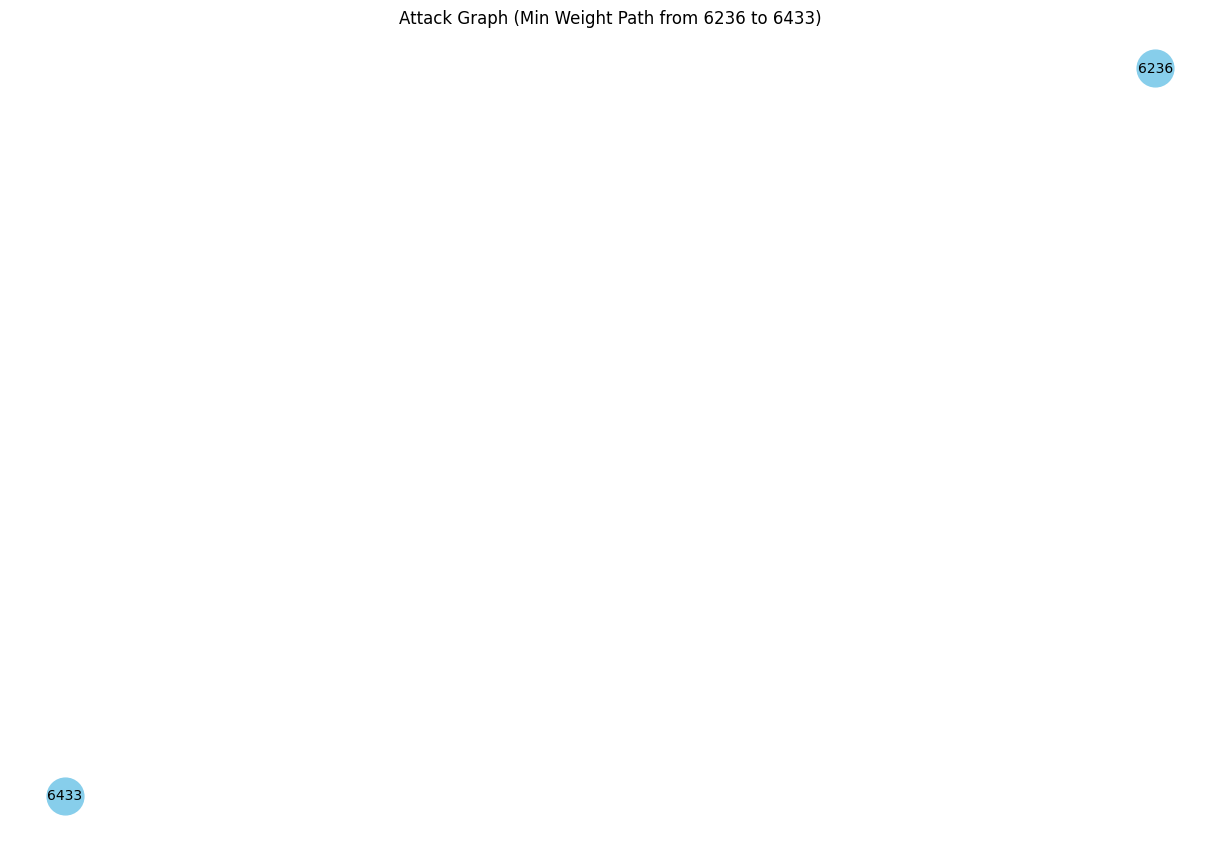

In [ ]:
# prompt: using min_weight_row plot the attack graph using networkx

import matplotlib.pyplot as plt

# Create a graph for the attack path
attack_graph = nx.DiGraph()

# Add nodes from the min_weight_row path
path_nodes_min = df_min_weight_paths['path']
for node_id in path_nodes_min:
    # Find the node properties from the original 'nodes' DataFrame
    node_info = nodes[nodes['id'] == node_id].iloc[0]
    attack_graph.add_node(node_id, label=node_info.get('name', str(node_id)), weight=node_info.get('weight', 1))

# Add edges from the min_weight_row path
for i in range(len(path_nodes_max) - 1):
    start_node = path_nodes_max[i]
    end_node = path_nodes_max[i+1]
    # Find the edge properties from the original 'edges' DataFrame
    edge_info = edges[(edges['start'] == start_node) & (edges['end'] == end_node)].iloc[0]
    attack_graph_max.add_edge(start_node, end_node, label=edge_info.get('label', 'Unknown'), weight=edge_info.get('weight', 1))

# Draw the graph
pos = nx.spring_layout(attack_graph)  # You can choose a different layout
for i, node_id in enumerate(path_nodes_min):
    pos_max[node_id] = (i, i) # Positions nodes diagonally
plt.figure(figsize=(12, 8))
nx.draw(attack_graph, pos, with_labels=False, node_size=700, node_color='skyblue', font_size=10, arrowsize=20)

# Add node labels
node_labels = nx.get_node_attributes(attack_graph, 'label')
nx.draw_networkx_labels(attack_graph, pos, labels=node_labels, font_size=10)

# Add edge labels
edge_labels = nx.get_edge_attributes(attack_graph, 'label')
nx.draw_networkx_edge_labels(attack_graph, pos, edge_labels=edge_labels, font_color='red')

plt.title(f"Attack Graph (Min Weight Path from {min_weight_row['source']} to {min_weight_row['target']})")
plt.show()

In [ ]:
# prompt: using max_weight_row plot the attack graph using networkx starting at the bottom left and ending up top right

import matplotlib.pyplot as plt
# Create a graph for the attack path using the max_weight_row
attack_graph_max = nx.DiGraph()

# Add nodes from the max_weight_row path
path_nodes_max = df_max_weight_paths['path']
for node_id in path_nodes_max:
    # Find the node properties from the original 'nodes' DataFrame
    node_info = nodes[nodes['id'] == node_id].iloc[0]
    attack_graph_max.add_node(node_id, label=node_info.get('name', str(node_id)), weight=node_info.get('weight', 1))

# Add edges from the max_weight_row path
for i in range(len(path_nodes_max) - 1):
    start_node = path_nodes_max[i]
    end_node = path_nodes_max[i+1]
    # Find the edge properties from the original 'edges' DataFrame
    edge_info = edges[(edges['start'] == start_node) & (edges['end'] == end_node)].iloc[0]
    attack_graph_max.add_edge(start_node, end_node, label=edge_info.get('label', 'Unknown'), weight=edge_info.get('weight', 1))

# Draw the graph
# Use a different layout that allows positioning
pos_max = {}
num_nodes = len(path_nodes_max)
# Simple linear positioning from bottom left to top right
for i, node_id in enumerate(path_nodes_max):
    pos_max[node_id] = (i, i) # Positions nodes diagonally

plt.figure(figsize=(12, 8))
nx.draw(attack_graph_max, pos_max, with_labels=False, node_size=700, node_color='lightblue', font_size=10, arrowsize=20)

# Add node labels
node_labels_max = nx.get_node_attributes(attack_graph_max, 'label')
nx.draw_networkx_labels(attack_graph_max, pos_max, labels=node_labels_max, font_size=10)

# Add edge labels
edge_labels_max = nx.get_edge_attributes(attack_graph_max, 'label')
nx.draw_networkx_edge_labels(attack_graph_max, pos_max, edge_labels=edge_labels_max, font_color='blue')

plt.title(f"Attack Graph (Max Weight Path from {max_weight_row['source']} to {max_weight_row['target']})")
plt.show()

ValueError: ('Lengths must match to compare', (10076,), (3,))

In [ ]:
/1


<>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
/tmp/ipython-input-94-691856829.py:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
  1()


TypeError: 'int' object is not callable

In [ ]:
df_shortest_paths_with_weight

In [ ]:
# prompt: for each source find minimum weight and target. if weight is the same print out all instances

import pandas as pd
# Group by source and find the minimum weight
min_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].min().reset_index()

# Merge with the original DataFrame to get rows with the minimum weight
result_min = pd.merge(df_shortest_paths_with_weight, min_weights, on=['source', 'total_weight'])

# Print the results
# for index, row in result.iterrows():
#   print(f"Source: {row['source']}, Target: {row['target']}, Minimum Weight: {row['total_weight']}, Path: {row['path']}")


In [ ]:
# prompt: for each source find MAXIMUM weight and target. only save the max results in result_max

import pandas as pd
# Group by source and find the maximum weight
max_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].max().reset_index()

# Merge with the original DataFrame to get rows with the maximum weight
result_max = pd.merge(df_shortest_paths_with_weight, max_weights, on=['source', 'total_weight'])

# Print the results
for index, row in result_max.iterrows():
  print(f"Source: {row['source']}, Target: {row['target']}, Maximum Weight: {row['total_weight']}, Path: {row['path']}")

In [ ]:
# prompt: for each source find minimum weight and target. if weight is the same print out all instances

import pandas as pd
# Group by source and find the minimum weight
max_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].max().reset_index()

# Merge with the original DataFrame to get rows with the minimum weight
result_max = pd.merge(df_shortest_paths_with_weight, max_weights, on=['source', 'total_weight'])

# Print the results
# for index, row in result.iterrows():
#   print(f"Source: {row['source']}, Target: {row['target']}, Max Weight: {row['total_weight']}, Path: {row['path']}")
# df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)
# df_shortest_paths_with_weight

In [ ]:
# prompt: for each source IN df_shortest_paths_with_weight find maximum weight and target AND PATH. if weight is the same print out all instances

# Iterate through each unique source node
for source_node in df_shortest_paths_with_weight['source'].unique():
    # Filter the DataFrame for the current source node
    source_df = df_shortest_paths_with_weight[df_shortest_paths_with_weight['source'] == source_node].copy()

    # Find the maximum weight for this source
    max_weight_for_source = source_df['total_weight'].max()

    # Filter for rows with the maximum weight for this source
    max_weight_paths = source_df[source_df['total_weight'] == max_weight_for_source]

    # Print the results for the current source
    print(f"\nSource: {source_node}")
    print(f"Maximum Weight for this source: {max_weight_for_source}")
    print("Paths with maximum weight:")
    for index, row in max_weight_paths.iterrows():
        print(f"  Target: {row['target']}, Path: {row['path']}")

In [ ]:
shortest_paths_with_weight

[{'source': 15, 'target': 301, 'path': [15, 301], 'total_weight': np.int64(2)},
 {'source': 15, 'target': 318, 'path': [15, 318], 'total_weight': np.int64(2)},
 {'source': 26, 'target': 331, 'path': [26, 331], 'total_weight': np.int64(2)},
 {'source': 26, 'target': 341, 'path': [26, 341], 'total_weight': np.int64(2)},
 {'source': 26, 'target': 357, 'path': [26, 357], 'total_weight': np.int64(2)},
 {'source': 26, 'target': 405, 'path': [26, 405], 'total_weight': np.int64(2)},
 {'source': 26, 'target': 444, 'path': [26, 444], 'total_weight': np.int64(2)},
 {'source': 26, 'target': 448, 'path': [26, 448], 'total_weight': np.int64(2)},
 {'source': 27, 'target': 392, 'path': [27, 392], 'total_weight': np.int64(2)},
 {'source': 29, 'target': 481, 'path': [29, 481], 'total_weight': np.int64(2)},
 {'source': 486,
  'target': 444,
  'path': [486, 444],
  'total_weight': np.int64(9)},
 {'source': 490,
  'target': 331,
  'path': [490, 331],
  'total_weight': np.int64(9)},
 {'source': 494,
  'targ

In [ ]:
result_min

In [ ]:
result_max

In [ ]:
# prompt: show me where source appears the most within the results_max dataframe. is ther one source that appears most

source_counts = result_max['source'].value_counts()

print("Count of each source in result_max:")
print(source_counts)

most_frequent_source = source_counts.index[0]
most_frequent_count = source_counts.iloc[0]

print(f"\nThe source that appears most frequently is: {most_frequent_source} with a count of {most_frequent_count}")

if most_frequent_count > 1:
  print("Yes, there is one source that appears most.")
else:
  print("No single source appears most frequently (or all sources appear only once).")

In [ ]:
source_counts_min = result_min['source'].value_counts()

print("Count of each source in result_max:")
print(source_counts_min)

most_frequent_source_min = source_counts.index[0]
most_frequent_count_min = source_counts.iloc[0]

print(f"\nThe source that appears most frequently is: {most_frequent_source} with a count of {most_frequent_count}")

if most_frequent_count_min > 1:
  print("Yes, there is one source that appears most.")
else:
  print("No single source appears most frequently (or all sources appear only once).")

In [ ]:
# prompt: convert result into a DataFrame

import pandas as pd
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)
df_shortest_paths_with_weight

NameError: name 'shortest_paths_with_weight' is not defined

In [ ]:
print(edges[edges['end'] == 301])

In [ ]:
shortest_paths_with_weight

In [ ]:
# prompt: for each node in shortest_paths_with_weight, find the minimum total_weight and the maxium total_weight, save it to a DataFrame

import pandas as pd
# Initialize a dictionary to store min and max weights for each target node
target_node_weights = {}

# Iterate through the shortest paths
for path_info in shortest_paths_with_weight:
    target_node = path_info['target']
    total_weight = path_info['total_weight']

    if target_node not in target_node_weights:
        target_node_weights[target_node] = {'min_weight': float('inf'), 'max_weight': float('-inf')}

    # Update min and max weights
    target_node_weights[target_node]['min_weight'] = min(target_node_weights[target_node]['min_weight'], total_weight)
    target_node_weights[target_node]['max_weight'] = max(target_node_weights[target_node]['max_weight'], total_weight)

# Convert the dictionary to a DataFrame
min_max_weights_df = pd.DataFrame.from_dict(target_node_weights, orient='index')
min_max_weights_df.index.name = 'target_node'
min_max_weights_df = min_max_weights_df.reset_index()

# Display the resulting DataFrame
print("\nMin and Max Total Weights for Each Target Node:")
min_max_weights_df

In [ ]:
# prompt: for each record in "for each record in "shortest_paths_filtered" add up the weights and find the smallest and largest combined weights and the path

# Find the path with the smallest total weight
min_weight_path_info = min(shortest_paths_with_weight, key=lambda item: item['total_weight'])

# Find the path with the largest total weight
max_weight_path_info = max(shortest_paths_with_weight, key=lambda item: item['total_weight'])

print("\nPath with the Smallest Combined Weight:")
print(f"Source: {min_weight_path_info['source']}, Target: {min_weight_path_info['target']}, Total Weight: {min_weight_path_info['total_weight']}, Path: {min_weight_path_info['path']}")

print("\nPath with the Largest Combined Weight:")
print(f"Source: {max_weight_path_info['source']}, Target: {max_weight_path_info['target']}, Total Weight: {max_weight_path_info['total_weight']}, Path: {max_weight_path_info['path']}")

In [ ]:
# prompt: for each record in "shortest_paths_filtered" add up the weights and find the smallest and largest combined weights and the path for the largest weight

# Function to calculate the total weight of a path
# def calculate_path_weight(graph, path):
#     total_weight = 0
#     for i in range(len(path) - 1):
#         # Add node weight
#         total_weight += graph.nodes[path[i]].get('weight', 0)
#         # Add edge weight
#         total_weight += graph[path[i]][path[i+1]].get('weight', 0)
#     # Add the weight of the last node in the path
#     if path:
#         total_weight += graph.nodes[path[-1]].get('weight', 0)
#     return total_weight

# all_path_weights = {}

# # Iterate through each source and its paths in shortest_paths_filtered
# for source, paths_from_source in shortest_paths_list.items():
#     all_path_weights[source] = {}
#     # Iterate through each target and its path
#     for target, path in paths_from_source.items():
#         # Calculate the weight of the path using the original graph G
#         weight = calculate_path_weight(G, path)
#         all_path_weights[source][target] = weight

# # Find the smallest and largest combined weights
# min_weight = float('inf')
# max_weight = float('-inf')
# largest_weight_path = None
# largest_weight_source = None
# largest_weight_target = None

# for source, paths_from_source in all_path_weights.items():
#     for target, weight in paths_from_source.items():
#         if weight < min_weight:
#             min_weight_source = source
#             min_weight_target = target
#             min_weight_path = shortest_paths_filtered[source][target]
#             min_weight = weight
#         if weight > max_weight:
#             max_weight = weight
#             largest_weight_source = source
#             largest_weight_target = target
#             largest_weight_path = shortest_paths_filtered[source][target]

# print(f"Smallest combined weight: {min_weight}")
# print(f"Path for the smallest weight: {min_weight_path}")
# print(f"Source for the smallest weight path: {min_weight_source}")
# print(f"Target for the smallest weight path: {min_weight_target}")
# print(f"Largest combined weight: {max_weight}")
# print(f"Path for the largest weight: {largest_weight_path}")
# print(f"Source for the largest weight path: {largest_weight_source}")
# print(f"Target for the largest weight path: {largest_weight_target}")

In [ ]:

print(nodes[nodes['id'] == 111])
print(nodes[nodes['id'] == 8])
print(nodes[nodes['id'] == 26])
#print(nodes[nodes['id'] == 444])
#print(nodes[nodes['id'] == 331])
#print(nodes[nodes['id'] == 208])

In [ ]:
selected_nodes

In [ ]:
selected_nodes

In [ ]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
shortest_paths

In [ ]:
shortest_paths_filtered

In [ ]:
# prompt: can you display the combined weight from the shortest_paths and display the path with the max weight

# Function to calculate the total weight of a path
def calculate_path_weight(graph, path):
    total_weight = 0
    # Add the weight of the starting node
    if path:
        total_weight += graph.nodes[path[0]].get('weight', 0) # Get node weight
    # Add the weight of the edges and the weights of subsequent nodes
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        # Add edge weight
        total_weight += graph.edges[u, v].get('weight', 0) # Get edge weight
        # Add weight of the next node
        total_weight += graph.nodes[v].get('weight', 0) # Get node weight
    return total_weight

max_weight = -1
max_path = None

# Iterate through the filtered shortest paths and calculate total weights
for source, paths in shortest_paths_filtered.items():
    for target, path in paths.items():
        current_weight = calculate_path_weight(G, path)
#        print(f"Path from {source} to {target}: {path}, Combined Weight: {current_weight}")
        if current_weight > max_weight:
            max_weight = current_weight
            max_path = path

print(f"\nPath with the maximum combined weight: {max_path}")
print(f"Maximum combined weight: {max_weight}")

In [ ]:
max_path
max_path = pd.DataFrame(max_path)
max_path.head()


In [ ]:
rename = {0: 'id'}
max_path = max_path.rename(columns=rename)
max_path

In [ ]:
# prompt: get label from nodes where id=max_path['id']

# Assuming max_path is a DataFrame with an 'id' column representing the node IDs in the max path
# and nodes is a DataFrame with 'id' and 'properties' columns.

# Get the list of node IDs from the max_path DataFrame
max_path_node_ids = max_path['id'].tolist()

# Filter the nodes DataFrame to get only the nodes that are in the max_path
nodes_in_max_path = nodes[nodes['id'].isin(max_path_node_ids)].copy()

# Now, extract the 'name' property from the 'properties' column for these nodes
# Use .loc to avoid SettingWithCopyWarning
# We use a lambda function with .apply to safely access nested dictionary keys.
max_path_node_labels = nodes_in_max_path.loc[:, 'properties'].apply(lambda x: x.get('name', ''))

print("Labels of nodes in the max path:")
print(max_path_node_labels.tolist())


In [ ]:
max_path

ignore from here


In [ ]:
vertices = nodes['id'].tolist()
vertices


In [ ]:
adj_list=adj.values.tolist()
len(adj_list)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def createAdjacencyMatrix(vertices,edges):
  noofvertices=len(vertices)
  adjM=[]
  while(len(adjM)<noofvertices):
    temp=[]
    for i in range(noofvertices):
      temp.append(0)
    adjM.append(temp)
  for edge in edges:
    i=edge[0]
    j=edge[1]
    if i>=noofvertices or j>=noofvertices or i<0 or j<0:
      print(f"Not a Proper Input in Edge {i},{j}")
    else:
      adjM[i][j]=1
      adjM[j][i]=1
#  G=nx.Graph()
#  G.add_edges_from(edges)
#  nx.draw_networkx(G)
#  plt.show()
  return adjM
vertices = vertices
edges = adj_list
adjM=createAdjacencyMatrix(vertices,edges)


In [ ]:
#adjM.shape
import numpy as np
len(adjM)
arr = np.array(adjM)

newarr = arr.reshape(10075, 10075)

print(newarr)

In [ ]:
def create_adjacency_matrix(V, edges):
    # Initialize an empty V x V matrix with all zeros
    matrix = [[0] * V for _ in range(V)]

    # Populate the matrix based on the edges
    for edge in edges:
        u, v = edge
        matrix[u][v] = 1
#       matrix[v][u] = 1  # Undirected graph

    return matrix
V1 = len(adj)
edges1 = adj[['start', 'end']].values.tolist()
adj_matrix1 = create_adjacency_matrix(V1, edges1)
for row in adj_matrix1:
    print(row)
print()

In [ ]:
type(adj)

In [ ]:
import pandas as pd

# Initialize an empty DataFrame to store selected records
selected_records = pd.DataFrame(columns=filtered_nodes_regex.columns)

# Iterate through each row of the filtered_nodes_regex DataFrame
for index, row in filtered_nodes_regex.iterrows():
    properties = row['properties']

    # Check if 'properties' is a dictionary and contains 'highvalue' and if 'highvalue' is True
    if isinstance(properties, dict) and 'highvalue' in properties and properties['highvalue'] == True:
        # Append the entire row to the selected_records DataFrame
        selected_records = pd.concat([selected_records, pd.DataFrame([row])], ignore_index=True)

# Display the selected_records DataFrame
print("Selected records where 'highvalue' is True:")
display(selected_records)

Selected records where 'highvalue' is True:


,id,properties,type,l1,l2,l3,weight


In [ ]:
# Create a new node ID based on the length of lastnode
new_node_id = int('9' * lastnode)

print(f"The new node ID is: {new_node_id}")

NameError: name 'lastnode' is not defined